# DSCI-235 Final Project
## Carcinization of Crime into Police Resistant Forms During the COVID-19 Pandemic
Andrew Barton, 4/24/2026

## A disclaimer:

The dataset for this project was too large for github's file size limit without compression. This jupyter notebook will not run without the uncompressed file. In order to view the contents of this notebook or run the code for yourself, please unzip the zip file included in the repo that contains the dataset before running this jupyter notebook. The file name is:

Crime_Data_from_2020_to_2024.zip
- the only file that should be contained within that zip file is:
Crime_Data_from_2020_to_2024.csv

Please ensure that file is unzipped to the same directory as this jupyter notebook before attempting to run any of the cells below this one.

Introduction:

As a Southern California native turned expatriate, I observed the cultural melting pot of Los Angeles county at various points throughout my childhood and in varying ways. I've seen racism perpetrated by people of every color, sometimes personally and sometimes systemically without any intention at all. However, I also left California when I became an adult, and so missed out on several years worth of change in the California social, political and even legal landscape between 2006 and 2020. It was then, with some interest, that I came across a dataset published for compliance with the FBI's 'National Incident-Based Reporting System'. This data detailed approximately 1mln crime incidents, including the date of report, date and time the incident occurred, the Los Angeles Police Division with jurisdiction over the incident and precise coordinates for the incident itself, various categorizations of incidents by both a crime code given by the LAPD and an incident description, victim characterization (though notably no characterization of a suspect), and a status on the outcome of the incident itself.

This dataset provides a great deal of useful detail, even if there are some theoretical issues with it. The data gives us the flexibility to answer a few questions with regard to changes that the COVID-19 pandemic had on the nature of crimes in Los Angeles, as well as provide metrics on how effective the LAPD was at adjusting to the challenges posed by COVID-19. We aim to test the hypothesis that the pandemic -- and the social distancing that was required by it -- caused crimes to change in nature by either intention or circumstance into types that are inherently resistant to policing, and further did nothing to prevent disparity in treatment across racial and ethnic groups.

First, we will discuss the limitations of the dataset, and then review the state of the environment at the start of the data collection -- elements that might have a confounding impact on the data we discover. Then we will seek to answer three questions that serve to help inform our hypothesis: what crimes comprised the time period covered in the dataset and how is it different from before the dataset collection began, are their arrest rate disparities in the demographics of the victims, and finally observe the changes to Intimate Partner Violence during the reported period to see if COVID-19 and resulting changes in daily life had impacts on it, and how those impacts differ from other types of assault in the reported period. Combining these three sets of information may shed some light on the changing nature of law enforcement and social dynamics during the pandemic and subsequent reintegration. Based on our findings, we may raise questions worth considering for the future of law enforcement policy and practice.

There are two clear limitations of this dataset that bear mentioning. The first, as mentioned before, being that the data contains only victim demographics and not suspect demographics. Due to this, we are unable to correlate the incidents and victim demographics with that of the suspects, and in so doing are prevented from gaining an understanding of what kind of people are most likely to be suspected of committing a crime in Los Angeles -- whether guilty or not. 

The omission of suspect demographics in the data creates a hole in the data where it is surprising to encounter one -- the data should have been easily obtained from LAPD police reporting, and would allow for the examination of law enforcement patterns in relation to suspect demographics. This would be extremely valuable to any policy that puts an emphasis on equity.

The absence of the data -- which ought to have been easy to collect given then nature of police reporting -- is conspicuous. Secondly, the data covers only part of the 2024 calendar year. In and of itself, this is no cause for concern, but may cause pollution of the data when comparing year-to-year. Due to these circumstances, this report will not include data for that year, and will instead focus on data for complete years. With these factors in mind, we will now get a feel for what the criminal environment of Los Angeles County looked like heading into the 2020s, and the pandemic.

In 2014, California passed Proposition 47, which changed specific property and drug charges from felony to misdemeanor. This led to a decrease in racial disparity in arrests and bookings, though fissures still remained -- specifically with respect to arrest rates against African Americans. (Lofstrom et al., 2020) In a broader sense, California's criminal justice reform had been largely successful in June of 2019, with the incarceration rate dropping from 476 to 314 per 100,000 residents compared to the same month in 2006.(Graves, 2020) This suggests that criminal reform to this point had been largely successful in LA County. In short -- California law reforms in the 2010s had largely been effective at reducing reported criminal activity.

With regard to events during the reported period that may be of note as markers for activity, there were three notable reforms passed during the first year of the data -- 2020. These include AB 2542, AB 1950, and SB 823. AB 2542, or the California Racial Justice act, prevented prosecutors from imposing a conviction or sentence based purely on race and allowed defendence to issue challenges in that regard.(American Bar Association, 2020) AB 1950 adjusted maximum probationary periods for felonies and misdemeanors, with the former decreasing from five years to two, and the later from three years to one.(BrownsteinLawGroup, 2023) SB 823 closed the state 'Division of Juvinile Justice', which gave county justice systems the ability to assist adolescents in need of guidance rather than hamstring their chance at a future.(BrownsteinLawGroup, 2023) The overall theme of this changing legislation is one of growth towards racial equity -- by preventing racially motivated prosecution it became harder for prejudiced prosecutors or judges to advance their beliefs. By reducing probationary periods for felonies and misdemeanors, focus was taken off of wasteful practicies that did little to reduce recidivism while encouraging greater legal exposure that would invite further technical violations. Finally, by offering youth the opportunity to change their trajectory back into something more socially acceptible, less repeat offenses were encouraged by the judicial system. This is the scene that our dataset opens on -- a county that has made significan strides towards preventing inequity, and has started to see dividends on the investment in the form of a lower reported crime rate.

# Crime Composition Over Time:

So, what types of crimes occurred in Los Angeles County over the reported period -- minus our partial year, 2024 -- and why does it matter? COVID social distancing and quarrantines dramatically reduced the incidence of street-based crime in Los Angeles County, by preventing access to those types of crime.(Campedelli et al., 2021; Mohler et al., 2020) To understand how COVID-19 impacted the nature of crime over time in Los Angeles, it would be beneficial to know whether that change persisted. If it did not persist, we will need to know how it changed. To ensure that each year is a valid comparison to the others, where there may have been a different total amount of crime, we will compare crime types by proportion rather than simple counts. This will be even more relevant with respect to 2020, where the county spent a significant amount of time under quarrantine.

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Read in data file.
data = pd.read_csv("Crime_Data_from_2020_to_2024.csv")
print(data.head())

       DR_NO               Date Rptd                DATE OCC  TIME OCC  AREA  \
0  211507896  04/11/2021 12:00:00 AM  11/07/2020 12:00:00 AM       845    15   
1  201516622  10/21/2020 12:00:00 AM  10/18/2020 12:00:00 AM      1845    15   
2  240913563  12/10/2024 12:00:00 AM  10/30/2020 12:00:00 AM      1240     9   
3  210704711  12/24/2020 12:00:00 AM  12/24/2020 12:00:00 AM      1310     7   
4  201418201  10/03/2020 12:00:00 AM  09/29/2020 12:00:00 AM      1830    14   

     AREA NAME  Rpt Dist No  Part 1-2  Crm Cd  \
0  N Hollywood         1502         2     354   
1  N Hollywood         1521         1     230   
2     Van Nuys          933         2     354   
3     Wilshire          782         1     331   
4      Pacific         1454         1     420   

                                         Crm Cd Desc  ... Status  Status Desc  \
0                                  THEFT OF IDENTITY  ...     IC  Invest Cont   
1     ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT  ...     

First, we organize the data into blocks of years with a new column.

In [47]:
# Parse dates and create a new column with only the year value.
data['DATE OCC'] = pd.to_datetime(data['DATE OCC'])
data['Year'] = data['DATE OCC'].dt.year
display(data.head())

C:\Users\deagl\AppData\Local\Temp\ipykernel_11404\3398807468.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data['DATE OCC'] = pd.to_datetime(data['DATE OCC'])


,DR_NO,Date Rptd,DATE OCC,TIME OCC,AREA,AREA NAME,Rpt Dist No,Part 1-2,Crm Cd,Crm Cd Desc,...,Status Desc,Crm Cd 1,Crm Cd 2,Crm Cd 3,Crm Cd 4,LOCATION,Cross Street,LAT,LON,Year
0,211507896,04/11/2021 12:00:00 AM,2020-11-07,845,15,N Hollywood,1502,2,354,THEFT OF IDENTITY,...,Invest Cont,354.0,NaN,NaN,NaN,7800 BEEMAN AV,NaN,34.2124,-118.4092,2020
1,201516622,10/21/2020 12:00:00 AM,2020-10-18,1845,15,N Hollywood,1521,1,230,"ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT",...,Invest Cont,230.0,NaN,NaN,NaN,ATOLL AV,N GAULT,34.1993,-118.4203,2020
2,240913563,12/10/2024 12:00:00 AM,2020-10-30,1240,9,Van Nuys,933,2,354,THEFT OF IDENTITY,...,Invest Cont,354.0,NaN,NaN,NaN,14600 SYLVAN ST,NaN,34.1847,-118.4509,2020
3,210704711,12/24/2020 12:00:00 AM,2020-12-24,1310,7,Wilshire,782,1,331,THEFT FROM MOTOR VEHICLE - GRAND ($950.01 AND ...,...,Invest Cont,331.0,NaN,NaN,NaN,6000 COMEY AV,NaN,34.0339,-118.3747,2020
4,201418201,10/03/2020 12:00:00 AM,2020-09-29,1830,14,Pacific,1454,1,420,THEFT FROM MOTOR VEHICLE - PETTY ($950 & UNDER),...,Invest Cont,420.0,NaN,NaN,NaN,4700 LA VILLA MARINA,NaN,33.9813,-118.4350,2020


Next, as discussed above, we will drop anything more recent than 2024, due to the data being for a partial year only.

In [48]:
# Drop all data as recent or newer than 2024.
data = data[data['Year'] < 2024]
display(data.tail())

,DR_NO,Date Rptd,DATE OCC,TIME OCC,AREA,AREA NAME,Rpt Dist No,Part 1-2,Crm Cd,Crm Cd Desc,...,Status Desc,Crm Cd 1,Crm Cd 2,Crm Cd 3,Crm Cd 4,LOCATION,Cross Street,LAT,LON,Year
877322,231606525,03/22/2023 12:00:00 AM,2023-03-22,1000,16,Foothill,1602,1,230,"ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT",...,Invest Cont,230.0,NaN,NaN,NaN,12800 FILMORE ST,NaN,34.2790,-118.4116,2023
877323,231716047,10/02/2023 12:00:00 AM,2023-09-25,2200,17,Devonshire,1798,2,740,"VANDALISM - FELONY ($400 & OVER, ALL CHURCH VA...",...,Invest Cont,740.0,NaN,NaN,NaN,8800 HASKELL AV,NaN,34.2302,-118.4764,2023
877324,230115220,07/02/2023 12:00:00 AM,2023-07-01,1,1,Central,154,1,352,PICKPOCKET,...,Invest Cont,352.0,NaN,NaN,NaN,500 S MAIN ST,NaN,34.0467,-118.2485,2023
877325,230906458,03/05/2023 12:00:00 AM,2023-03-05,900,9,Van Nuys,914,2,745,VANDALISM - MISDEAMEANOR ($399 OR UNDER),...,Invest Cont,745.0,NaN,NaN,NaN,14500 HARTLAND ST,NaN,34.1951,-118.4487,2023
877326,230319786,11/10/2023 12:00:00 AM,2023-11-09,2300,3,Southwest,395,1,331,THEFT FROM MOTOR VEHICLE - GRAND ($950.01 AND ...,...,Invest Cont,331.0,NaN,NaN,NaN,4100 S HOBART BL,NaN,34.0091,-118.3078,2023


Now we categorize the data into on of four different categories -- intimate partner, violent, property or 'other'. This will enable us to determine what proportion of the total crime falls into each category.

In [49]:
crime_by_type = data.copy()

# Create data masks.
conditions = [
    crime_by_type['Crm Cd Desc'].str.contains('INTIMATE PARTNER', case=False, na=False),
    crime_by_type['Crm Cd Desc'].str.contains('ASSAULT|ROBBERY|HOMOCIDE|RAPE|KIDNAP', case=False, na=False),
    crime_by_type['Crm Cd Desc'].str.contains('BURGLARY|THEFT|VANDALISM|VEHICLE', case=False, na=False),
]

choices = ['Intimate Partner Violence', 'Violent', 'Property']

# Select data using conditions and choices while sorting anyting else into 'Other'.
crime_by_type['Category'] = np.select(conditions, choices, default = 'Other')

display(crime_by_type.head())

,DR_NO,Date Rptd,DATE OCC,TIME OCC,AREA,AREA NAME,Rpt Dist No,Part 1-2,Crm Cd,Crm Cd Desc,...,Crm Cd 1,Crm Cd 2,Crm Cd 3,Crm Cd 4,LOCATION,Cross Street,LAT,LON,Year,Category
0,211507896,04/11/2021 12:00:00 AM,2020-11-07,845,15,N Hollywood,1502,2,354,THEFT OF IDENTITY,...,354.0,NaN,NaN,NaN,7800 BEEMAN AV,NaN,34.2124,-118.4092,2020,Property
1,201516622,10/21/2020 12:00:00 AM,2020-10-18,1845,15,N Hollywood,1521,1,230,"ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT",...,230.0,NaN,NaN,NaN,ATOLL AV,N GAULT,34.1993,-118.4203,2020,Violent
2,240913563,12/10/2024 12:00:00 AM,2020-10-30,1240,9,Van Nuys,933,2,354,THEFT OF IDENTITY,...,354.0,NaN,NaN,NaN,14600 SYLVAN ST,NaN,34.1847,-118.4509,2020,Property
3,210704711,12/24/2020 12:00:00 AM,2020-12-24,1310,7,Wilshire,782,1,331,THEFT FROM MOTOR VEHICLE - GRAND ($950.01 AND ...,...,331.0,NaN,NaN,NaN,6000 COMEY AV,NaN,34.0339,-118.3747,2020,Property
4,201418201,10/03/2020 12:00:00 AM,2020-09-29,1830,14,Pacific,1454,1,420,THEFT FROM MOTOR VEHICLE - PETTY ($950 & UNDER),...,420.0,NaN,NaN,NaN,4700 LA VILLA MARINA,NaN,33.9813,-118.4350,2020,Property


In [50]:
# Retrieve the proportion of each type of crime by year.
crime_proportions_by_type = crime_by_type.groupby(['Year', 'Category']).size().unstack().apply(lambda x: x / x.sum(), axis=1)
display(crime_proportions_by_type)

Category,Intimate Partner Violence,Other,Property,Violent
Year,,,,
2020,0.068893,0.150400,0.583126,0.197581
2021,0.066049,0.148173,0.591573,0.194205
2022,0.059836,0.140224,0.614952,0.184988
2023,0.059700,0.145357,0.607665,0.187278


This table represents the proportion of total crime each category composes for each year.

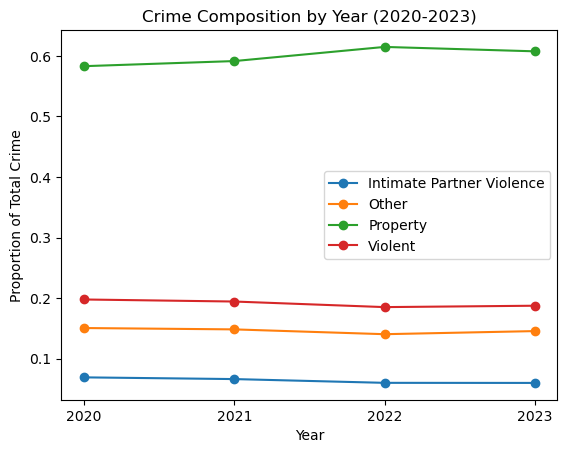

In [51]:
fig, ax = plt.subplots()

for column in crime_proportions_by_type.columns:
    ax.plot(crime_proportions_by_type.index, crime_proportions_by_type[column], marker='o', label=column)

ax.legend()
ax.set_xlabel('Year')
ax.set_ylabel('Proportion of Total Crime')
ax.set_title('Crime Composition by Year (2020-2023)')
ax.set_xticks([2020, 2021, 2022, 2023])
plt.show()

As depicted by the chart above, incidents of IPV increased beginning with the start of the pandemic and elevated through 2021 before starting to level off in 2023. Though harder to notice in the other three categories, there is a very slight decline in incidents through 2020 and persisting into 2022 before beginning to plateau or level off. This points to crime shifting from a type that is more accessible to law enforcement in public to one that is more difficult for public police to be made aware of or assist with.

# Arrest Rate Demographics Among Victims

Prior to exploring the data, it is worth naming a limitation on the answer that the data is capable of providing. That being, the result -- a disparity in arrest rates for a given demographic -- could represent a number of conclusions, and divining the difference between them is beyond the scope of this analysis. These conclusions include, but may not be limited to: the disparity reflects deliberate choices made by law enforcement agencies or individual officers rather than circumstance or confounding factors, that crimes perpetrated against that demographic of victim are inherently harder to solve for systemic reasons, or that the types of crimes committed against that demographic are substantially different in a way that makes solving them problematic. The differentiation between these possible conclusions are not possible to prove using this dataset alone, and would require further research to have any epistemic footing.

With this in mind, we continue onto our second question: is there a disparity in arrest rates amongst victim demographics during the reported period? This serves to answer the hypothesis from a different perspective. Did the compounding issues of economic, social, and emotional pressures created by the COVID-19 pandemic and subsequent reintegration cause impacts to equity in law enforcement? Are there changes present in the data that correlate to specific incidents, changes in legislation or public policy during the reporting period that indicate policies that created greater inequity rather than removing it?

In [52]:
arrests_df = data.copy()

# Create a map for each code to a demographic.
demo_map = {
    'H': 'Hispanic/Latin',
    'W': 'White',
    'B': 'Black',
    'A': 'Asian'
}

# Add the data to a new column of the dataframe.
arrests_df['Descent'] = arrests_df['Vict Descent'].map(demo_map).fillna('Other/Unknown')

# Create a new column and add a boolean to it for whether the crime resulted in an arrest or not.
arrests_df['Arrested'] = arrests_df['Status Desc'].isin(['Adult Arrest', 'Juv Arrest'])

# Retrieve the arrest rates for each demographic by taking the mean of each.
arrest_rates = arrests_df.groupby('Descent')['Arrested'].mean()

display(arrest_rates)

Descent
Asian             0.087182
Black             0.087336
Hispanic/Latin    0.125649
Other/Unknown     0.077336
White             0.080019
Name: Arrested, dtype: float64

In [53]:
# Retrieve the arrest rates year over year by taking the mean by each year for every demographic.
arrests_yoy = arrests_df.groupby(['Year', 'Descent'])['Arrested'].mean().unstack()

display(arrests_yoy)

Descent,Asian,Black,Hispanic/Latin,Other/Unknown,White
Year,,,,,
2020,0.090173,0.097655,0.141869,0.087749,0.092171
2021,0.092760,0.097770,0.131981,0.073860,0.079891
2022,0.089637,0.078276,0.115564,0.073109,0.073391
2023,0.077472,0.077564,0.116065,0.076165,0.075468


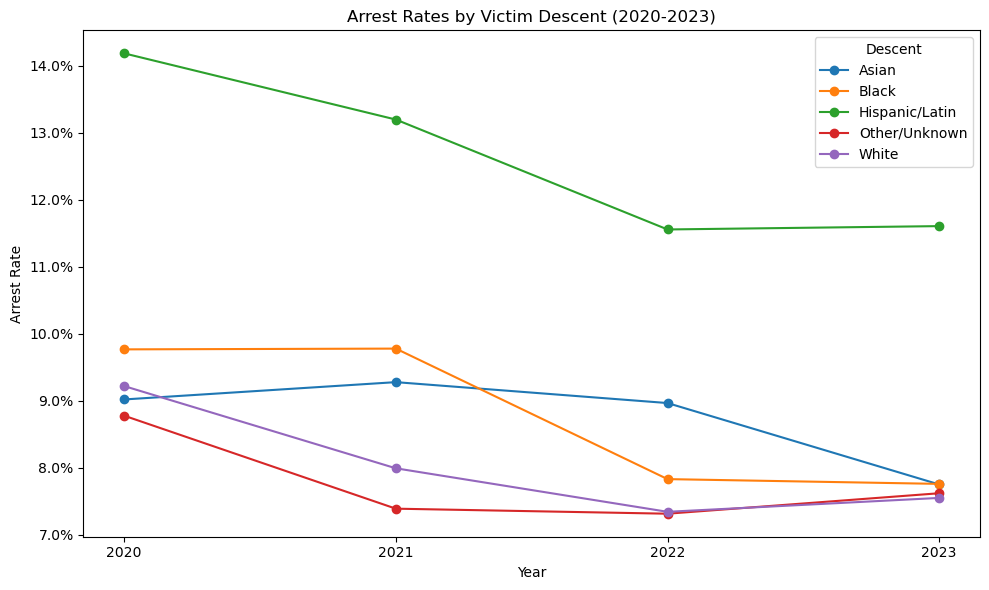

In [54]:
fig, ax = plt.subplots(figsize=(10, 6))

arrests_yoy.plot(marker='o', ax=ax)

ax.set_title('Arrest Rates by Victim Descent (2020-2023)')
ax.set_xlabel('Year')
ax.set_ylabel('Arrest Rate')
ax.set_xticks([2020, 2021, 2022, 2023])
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda y, _: f'{y:.1%}')
)

plt.tight_layout()
plt.show()

This data shows a few interesting points that bear mentioning: first, is the notable drop in arrest rates across most demographics during 2020. This was to be expected due to the massive drop in access because of quarantining and social distancing, but what comes after it is more interesting. Arrest rates for all non-white races except for Latin converge around the same percentage: between 7.5 and 8 percent. The outlier of the group is Latin victims, who continue to experience a much higher arrest rate than other races during the reporting period. The cause of this is ambiguous, as discussed in the introductory paragraph of this section -- however, these points are all worthy of note as we approach evaluation of our hypothesis.

# Intimate Partner Violence in Los Angeles and COVID-19 

How did the COVID-19 pandemic transform the landscape of arrests across Los Angeles from 2020 to 2023? The easiest way to tell is by taking the data that we've worked with up to this point -- where we have filtered out the 2024 data and ensured that the records correspond to confirmed arrests, and have organized the victim demographics into usable categories. With this data, we will see how the incidents of these crimes changed year over year without demographic data considered.

In [55]:
# Retrieve only incidents of intimate partner violence from the previously filtered dataframe with 2024 data removed and only containing arrests.
ipv_demo_df = arrests_df[arrests_df['Crm Cd Desc'].str.contains('INTIMATE PARTNER', case=False, na=False)].copy()

display(ipv_demo_df.head())

,DR_NO,Date Rptd,DATE OCC,TIME OCC,AREA,AREA NAME,Rpt Dist No,Part 1-2,Crm Cd,Crm Cd Desc,...,Crm Cd 2,Crm Cd 3,Crm Cd 4,LOCATION,Cross Street,LAT,LON,Year,Descent,Arrested
16,201820230,11/08/2020 12:00:00 AM,2020-11-08,730,18,Southeast,1844,2,626,INTIMATE PARTNER - SIMPLE ASSAULT,...,NaN,NaN,NaN,108TH ST,AVALON AV,33.9383,-118.2652,2020,Black,False
29,202013248,08/09/2020 12:00:00 AM,2020-08-09,2250,20,Olympic,2069,2,626,INTIMATE PARTNER - SIMPLE ASSAULT,...,NaN,NaN,NaN,1200 S WESTMORELAND AV,NaN,34.0495,-118.2891,2020,Hispanic/Latin,True
32,201809657,04/15/2020 12:00:00 AM,2020-04-15,1550,18,Southeast,1871,2,626,INTIMATE PARTNER - SIMPLE ASSAULT,...,NaN,NaN,NaN,800 W ROSECRANS AV,NaN,33.9019,-118.2893,2020,Black,False
86,201805731,02/01/2020 12:00:00 AM,2020-02-01,1330,18,Southeast,1822,2,626,INTIMATE PARTNER - SIMPLE ASSAULT,...,NaN,NaN,NaN,10100 S BROADWAY,NaN,33.9447,-118.2784,2020,Hispanic/Latin,False
87,202018701,12/22/2020 12:00:00 AM,2020-12-22,150,20,Olympic,2069,2,626,INTIMATE PARTNER - SIMPLE ASSAULT,...,NaN,NaN,NaN,2300 W PICO BL,NaN,34.0499,-118.2879,2020,Other/Unknown,False


In [56]:
# Retrieve overall arrests for IPV crimes by year.
ipv_yoy = ipv_demo_df.groupby('Year').size()
display(ipv_yoy)

Year
2020    13768
2021    13862
2022    14077
2023    13871
dtype: int64

<function matplotlib.pyplot.show(close=None, block=None)>

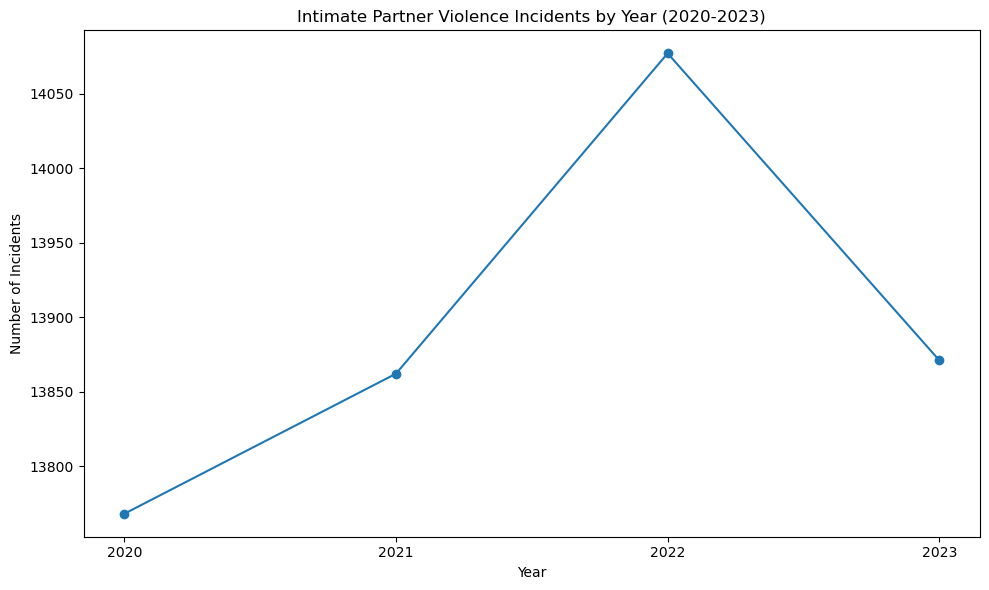

In [57]:
fig, ax = plt.subplots(figsize=(10, 6))
ipv_yoy.plot(marker='o', ax=ax)
ax.set_title('Intimate Partner Violence Incidents by Year (2020-2023)')
ax.set_xlabel('Year')
ax.set_ylabel('Number of Incidents')
ax.set_xticks([2020, 2021, 2022, 2023])
plt.tight_layout()
plt.show

Here we see a striking depiction of IPV reports during the reported period in a very striking way -- as suggested by the environment of Los Angeles going into the reporting period, the stresses caused by the pandemic caused interpersonal violence to surge with a notable peak of over 14,000 reports in 2022. However, this sharply drops off again after the peak to a level consistent to the year before it. This suggests that it may have been in the best public interest for free couple's counseling to have been made available, or for community organized spaces for exercise during quarantine. However, it is important to highlight again that the data only suggests a peak in IPV reporting during the period of recovery and reintegration from the pandemic.

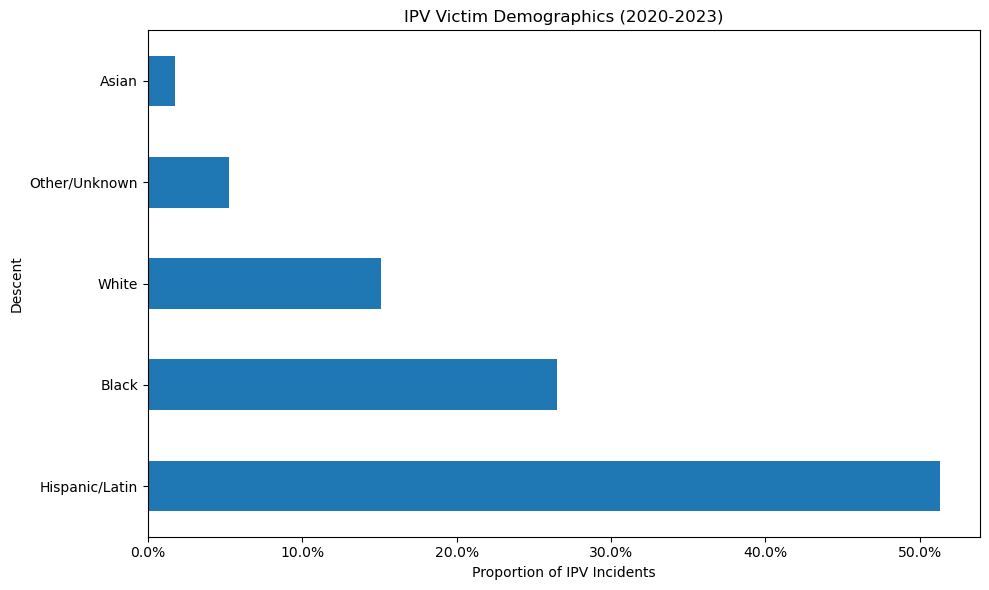

In [58]:
# Retrieve the counts of IPV for each demographic and normalize them.
ipv_demos = ipv_demo_df['Descent'].value_counts(normalize=True)

fig, ax = plt.subplots(figsize=(10, 6))
ipv_demos.plot(kind='barh', ax=ax)
ax.set_title('IPV Victim Demographics (2020-2023)')
ax.set_xlabel('Proportion of IPV Incidents')
ax.xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'{x:.1%}')
)
plt.tight_layout()
plt.show()

From the above bar graph, we can see that the overwhelming majority of IPV victims during the reported period were of Latin descent, with other cultures following a logarithmic dispersion from there on, with Black victims at approximately half of the Latin victims, White victims at half of the Black victims, and the remaining half consisting of other races or a much smaller contingent of Asians when compared to the rest of the population. This could be for any number of reasons, up to but not including: an abundance of willingness for Hispanic victims to report IPV to law enforcement, Hispanic communities in Los Angeles may be more common in areas more frequently patrolled by the LAPD, socioeconomic issues correlated with demographic composition may influence IPV in a way unable to be accounted for by this report, and the data only reflects incident reporting -- not incidence. This could be easily confused with perfect reporting, which may lead to a misunderstanding of the data presented.

In [59]:
# Retrieve arrest rates for IPV by demographic, year over year.
ipv_arr_yoy = ipv_demo_df.groupby(['Year', 'Descent'])['Arrested'].mean().unstack()

# Drop the 'Other/Unknown' column to prevent data pollution.
ipv_arr_yoy = ipv_arr_yoy.drop(columns='Other/Unknown')
display(ipv_arr_yoy.head())

Descent,Asian,Black,Hispanic/Latin,White
Year,,,,
2020,0.339921,0.178835,0.295307,0.305994
2021,0.339286,0.177524,0.286104,0.272422
2022,0.281588,0.141543,0.263691,0.260553
2023,0.256410,0.143385,0.242122,0.235323


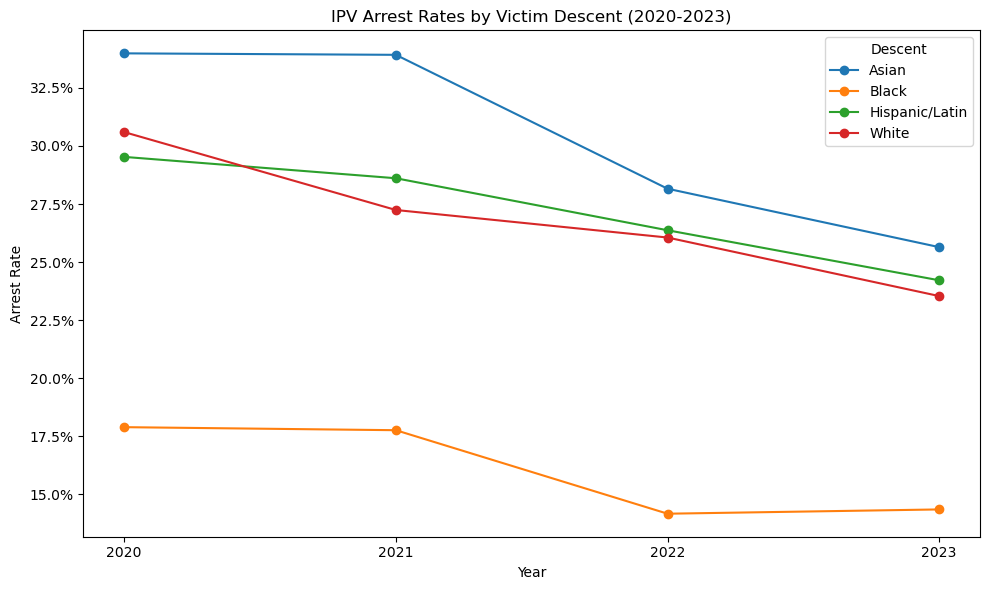

In [60]:
fig, ax = plt.subplots(figsize=(10, 6))
ipv_arr_yoy.plot(marker='o', ax=ax)
ax.set_title('IPV Arrest Rates by Victim Descent (2020-2023)')
ax.set_xlabel('Year')
ax.set_ylabel('Arrest Rate')
ax.set_xticks([2020, 2021, 2022, 2023])
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda y, _: f'{y:.1%}')
)
plt.tight_layout()
plt.show()

Finally, with the above figure we see an interesting disparity. During the reported period, approximately a quarter of all IPV incidents that were reported to police had Black victims, but the arrest rates for IPV crimes with Black victims is disproportionately lower than other demographics, coming in at near 15% in 2023, down from near 17% in 2021. This curious outlier points to reports Black victims of IPV resulting in disproportionately lower arrests by a non-trivial factor. When combining this information with the known limitation of this study -- that it reflects only reported data than the total number of incidents -- it becomes likely that underreporting is occurring on top of an already disproportionately lower reporting rate. This suggests that Black IPV victims in LA county are likely suffering in silence rather than reporting the crimes to their authorities for help.

# Conclusion:

At the onset of this report, the hypothesis for it was defined as: did the pandemic -- and the social distancing that was required by it -- cause crimes to change in nature by either intention or circumstance into types that are inherently resistant to policing, and further did nothing to prevent disparity in treatment across racial and ethnic groups.

After reviewing our data, we found evidence to suggest that incidents of IPV spiked in the years immediately following the pandemic, that Hispanics were disproportionately more likely to be arrested in Los Angeles County during the reported period, and that Black victims of intimate partner violence are less likely to see an arrest made on their behalf when they report it. What story does this tell?

It tells of a city that entered an unprecedented  period of human history with strong intentions for reducing inequity, but ultimately fell short in execution. The data for the reported period is not of a city's law enforcement organization with things well in hand, but one that reacted reflexively to the pressures that the pandemic caused, to the disproportionate suffering of Blacks living in the city. The specific causes of this are unclear from the data alone, but further research is clearly needed into exploring the reasons behind the disparate rate that African American Los Angeleans are suffering in silence from intimate partner violence rather than seeking help from their stated civil servants.

# Works Cited:

Campedelli, G. M., Aziani, A., & Favarin, S. (2021). Exploring the immediate effects of COVID-19 containment policies on crime: An empirical analysis of the short-term aftermath in Los Angeles. American Journal of Criminal Justice, 46(5), 831–851. https://doi.org/10.1007/s12103-020-09578-6

Graves, S. (2020, August). Criminal justice reform is working in California. California Budget & Policy Center. https://calbudgetcenter.org/resources/criminal-justice-reform-is-working-in-california/

Lofstrom, M., Martin, B., & Raphael, S. (2020, June). Proposition 47's impact on racial disparity in criminal justice outcomes. Public Policy Institute of California. https://www.ppic.org/publication/proposition-47s-impact-on-racial-disparity-in-criminal-justice-outcomes/

Males, M. A. (2023). Don't blame criminal justice reforms for crime increases during the COVID pandemic. Center on Juvenile and Criminal Justice. https://www.cjcj.org/news/blog/dont-blame-criminal-justice-reforms-2010-2019-for-crime-increases-during-the-covid-pandemic-2020-22-the-two-eras-trends-are-dramatically

Mohler, G., Bertozzi, A. L., Carter, J., Short, M. B., Sledge, D., Tita, G. E., Uchida, C. D., & Brantingham, P. J. (2020). Impact of social distancing during COVID-19 pandemic on crime in Los Angeles and Indianapolis. Journal of Criminal Justice, 68, 101692. https://doi.org/10.1016/j.jcrimjus.2020.101692

Piquero, A. R., Jennings, W. G., Jemison, E., Kaukinen, C., & Knaul, F. M. (2021). Domestic violence during the COVID-19 pandemic: Evidence from a systematic review and meta-analysis. Journal of Criminal Justice, 74, 101806. https://doi.org/10.1016/j.jcrimjus.2021.101806

Robinette, J. W., Edwards, T. M., & Bush, N. (2022). Intimate partner violence at a level-1 trauma center during the COVID-19 pandemic: An interrupted time series analysis. Trauma Surgery & Acute Care Open, 7(1). https://doi.org/10.1136/tsaco-2021-000888

Shafer, A., Fitzgerald, S., & Wearing, S. (2022). Prevalence and correlates of intimate partner violence during COVID-19: A rapid review. Journal of Family Violence, 37(8), 1233–1246. https://doi.org/10.1007/s10896-022-00386-6

The American Bar Association. (2020, Fall). California legislature confronts racial discrimination in new criminal justice reform package. https://www.americanbar.org/groups/committees/death_penalty_representation/project_press/2020/fall-2020/california-criminal-justice-reform-package/

The Brownstein Law Group. (2023). California's new criminal justice reforms: What they mean for defendants. https://www.brownsteinlawgroup.com/blog/californias-new-criminal-justice-reforms-what-they-mean-for-defendants/